# CS-4063 — Natural Language Processing
## Assignment 2 — Neural NLP Pipeline
### FAST NUCES | PyTorch from Scratch

**GitHub URL:** `https://github.com/dilawaiz-hameed/i23-2518-NLP-Assignment2`

---

## Setup & Imports

In [3]:
import os, re, json, math, random, time
from collections import Counter, defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

# Paths
CLEANED_PATH = 'cleaned.txt'
RAW_PATH     = 'raw.txt'
META_PATH    = 'Metadata.json'
EMB_DIR      = 'embeddings'
DATA_DIR     = 'data'
MODEL_DIR    = 'models'
os.makedirs(EMB_DIR,   exist_ok=True)
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

Using device: cpu
PyTorch version: 2.10.0+cpu


## Data Loading Utilities

In [4]:
def load_articles(path):
    """
    Parse cleaned.txt / raw.txt.
    Each article is delimited by a [N] marker on its own line.
    Tokens in cleaned.txt are pipe-separated; raw.txt has plain Urdu text.
    Returns list of token lists (one per article).
    """
    with open(path, encoding='utf-8') as f:
        content = f.read()

    # Split on article markers like [1], [2], ...
    parts = re.split(r'\[\d+\]', content)
    articles = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        # cleaned.txt uses pipe-separated tokens; raw.txt has plain words
        if '|' in part:
            tokens = [t.strip() for t in part.split('|')
                      if t.strip() and t.strip() not in ('', '\n')]
        else:
            tokens = part.split()
        if tokens:
            articles.append(tokens)
    return articles

cleaned_articles = load_articles(CLEANED_PATH)
raw_articles     = load_articles(RAW_PATH)
print(f'Cleaned corpus: {len(cleaned_articles)} articles')
print(f'Raw corpus    : {len(raw_articles)} articles')
print(f'Sample tokens (cleaned[0][:10]): {cleaned_articles[0][:10]}')

# Load metadata
with open(META_PATH, encoding='utf-8') as f:
    metadata = json.load(f)
print(f'Metadata entries: {len(metadata)}')

Cleaned corpus: 158 articles
Raw corpus    : 185 articles
Sample tokens (cleaned[0][:10]): ['کولمبو', '\u202b<NUM>\u202c', 'فرور', '\u202b<NUM>\u202c', 'ٹی', '\u202b<NUM>\u202c', 'ورلڈ', 'کپ', '\u202b<NUM>\u202c', 'کا']
Metadata entries: 203


---
# Part 1 — Word Embeddings [25 Marks]
## 1.1 TF-IDF Weighting [4 marks]

In [5]:
# ── 1.1  TF-IDF ──────────────────────────────────────────────────────────────
MAX_VOCAB = 10_000

# 1. Build vocabulary (top-10K by frequency)
all_tokens = [t for art in cleaned_articles for t in art]
freq = Counter(all_tokens)
top_tokens = [w for w, _ in freq.most_common(MAX_VOCAB)]
vocab   = {w: i for i, w in enumerate(top_tokens)}
vocab['<UNK>'] = len(vocab)
V = len(vocab)
UNK_IDX = vocab['<UNK>']
print(f'Vocabulary size (incl. <UNK>): {V}')

# index → word mapping
idx2word = {i: w for w, i in vocab.items()}

# Save word2idx
with open(os.path.join(EMB_DIR, 'word2idx.json'), 'w', encoding='utf-8') as f:
    json.dump(vocab, f, ensure_ascii=False)
print('word2idx.json saved.')

Vocabulary size (incl. <UNK>): 5871
word2idx.json saved.


In [6]:
def build_tfidf(articles, vocab, max_vocab=10_000):
    """
    Build a TF-IDF term-document matrix.
    Shape: (num_docs, vocab_size)
    TF-IDF(w,d) = TF(w,d) * log(N / (1 + df(w)))
    """
    N = len(articles)
    V = len(vocab)
    UNK = vocab['<UNK>']

    # Term-frequency matrix (sparse build then dense store)
    tf_matrix = np.zeros((N, V), dtype=np.float32)
    df = np.zeros(V, dtype=np.int32)

    for d_idx, tokens in enumerate(articles):
        doc_len = max(len(tokens), 1)
        token_ids = [vocab.get(t, UNK) for t in tokens]
        tf_count = Counter(token_ids)
        for tid, cnt in tf_count.items():
            tf_matrix[d_idx, tid] = cnt / doc_len
            df[tid] += 1

    # IDF with smoothing
    idf = np.log(N / (1.0 + df.astype(np.float32)))  # shape: (V,)

    # TF-IDF
    tfidf_matrix = tf_matrix * idf[np.newaxis, :]     # broadcast
    return tfidf_matrix, idf, df

tfidf_matrix, idf, df = build_tfidf(cleaned_articles, vocab)
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
np.save(os.path.join(EMB_DIR, 'tfidf_matrix.npy'), tfidf_matrix)
print('tfidf_matrix.npy saved.')

TF-IDF matrix shape: (158, 5871)
tfidf_matrix.npy saved.


In [7]:
# ── Top-10 most discriminative words per topic category ─────────────────────
# Assign each article an approximate topic via keyword heuristics
TOPIC_KEYWORDS = {
    'Politics' : ['حکومت','وزیر','پارلیمنٹ','الیکشن','سیاست','وزیراعظم','صدر','اسمبل','وزارت'],
    'Sports'   : ['کرکٹ','میچ','ٹیم','کھلاڑ','اسکور','ورلڈ','ٹورنامنٹ','بیٹنگ','باؤلنگ','فٹبال'],
    'Economy'  : ['معیشت','روپ','بینک','بجٹ','تجارت','مہنگائ','جی ڈی پی','سرمایہ','اقتصاد'],
    'Intl'     : ['اقوام متحدہ','معاہد','خارج','سفارت','بین الاقوامی','جنگ','تنازع'],
    'Health'   : ['ہسپتال','بیمار','ویکسین','سیلاب','تعلیم','صحت','ڈاکٹر','دوائ','وبا'],
}

def assign_topic(tokens):
    counts = {t: 0 for t in TOPIC_KEYWORDS}
    token_set = set(tokens)
    for topic, kws in TOPIC_KEYWORDS.items():
        for kw in kws:
            if kw in token_set:
                counts[topic] += 1
    best = max(counts, key=counts.get)
    return best

article_topics = [assign_topic(art) for art in cleaned_articles]
topic_counts = Counter(article_topics)
print('Article distribution by topic:', topic_counts)

# Group document indices by topic
topic_doc_ids = defaultdict(list)
for d_idx, topic in enumerate(article_topics):
    topic_doc_ids[topic].append(d_idx)

print('\nTop-10 most discriminative words per topic (by mean TF-IDF):')
top10_per_topic = {}
for topic, ids in topic_doc_ids.items():
    mean_scores = tfidf_matrix[ids].mean(axis=0)  # shape (V,)
    top10_idx   = np.argsort(mean_scores)[::-1][:10]
    top10_words = [idx2word[i] for i in top10_idx]
    top10_per_topic[topic] = top10_words
    print(f'  {topic}: {top10_words}')

Article distribution by topic: Counter({'Politics': 110, 'Sports': 38, 'Health': 4, 'Economy': 3, 'Intl': 3})

Top-10 most discriminative words per topic (by mean TF-IDF):
  Sports: ['کرکٹ', 'بھارت', 'ورلڈ', 'کپ', 'وکٹ', 'کولمبو', 'پاک', 'مقابل', 'ٹی', 'میچ']
  Politics: ['کراچ', 'ایران', 'فلم', 'حکومت', 'خان', 'زلزل', 'عمران', 'اداکار', 'ٹی', 'بان']
  Health: ['تھیٹر', 'پتل', 'رضائ', 'رفیع', 'مضامین', 'گرن', 'موسیٰ', 'پیر', 'گریڈ', 'امتحان']
  Economy: ['سون', 'کرنسی', 'قیمت', 'ریٹ', 'معیشت', 'ڈالر،', 'درہم،', 'مشرق', 'ریال', 'وسطیٰ']
  Intl: ['پیٹر', 'سائر', 'کشمیر', 'لیڈز', 'شی', 'فلم', 'خواتین', 'نیشنز', 'انڈی', 'اداکار']


## 1.2 Pointwise Mutual Information (PMI) [5 marks]

In [8]:
# ── 1.2  PPMI ────────────────────────────────────────────────────────────────
WINDOW_K = 5

def build_ppmi(articles, vocab, window=5):
    """
    Build PPMI word-word co-occurrence matrix.
    Shape: (V, V) — symmetric context window of size k.
    PPMI(w1,w2) = max(0, log2(P(w1,w2) / (P(w1)*P(w2))))
    """
    V   = len(vocab)
    UNK = vocab['<UNK>']

    cooc = np.zeros((V, V), dtype=np.float64)
    word_count = np.zeros(V, dtype=np.float64)

    for tokens in articles:
        ids = [vocab.get(t, UNK) for t in tokens]
        for i, w in enumerate(ids):
            word_count[w] += 1
            lo = max(0, i - window)
            hi = min(len(ids), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    cooc[w, ids[j]] += 1

    total = cooc.sum()
    if total == 0:
        return cooc

    # joint probability
    P_ww = cooc / total
    # marginal probabilities
    P_w  = word_count / word_count.sum()

    # PPMI — compute row by row to avoid a huge V×V / V×V broadcast
    ppmi = np.zeros((V, V), dtype=np.float32)
    for i in range(V):
        if P_w[i] == 0:
            continue
        # P(w1,w2) / (P(w1)*P(w)) for all w2
        denom = P_w[i] * P_w          # shape (V,)
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(denom > 0, P_ww[i] / denom, 0.0)
            log_r = np.where(ratio > 0, np.log2(ratio), 0.0)
        ppmi[i] = np.maximum(0.0, log_r)

    return ppmi

print('Building PPMI matrix (may take a few minutes)...')
t0 = time.time()
ppmi_matrix = build_ppmi(cleaned_articles, vocab, window=WINDOW_K)
print(f'PPMI matrix shape: {ppmi_matrix.shape}  [{time.time()-t0:.1f}s]')
np.save(os.path.join(EMB_DIR, 'ppmi_matrix.npy'), ppmi_matrix)
print('ppmi_matrix.npy saved.')

Building PPMI matrix (may take a few minutes)...
PPMI matrix shape: (5871, 5871)  [1.9s]
ppmi_matrix.npy saved.


Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_10955/2285524363.py:42: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10955/2285524363.py:42: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_10955/2285524363.py:42: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10955/2285524363.py:42: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10955/2285524363.py:43: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig('tsne_ppmi.png', dpi=150)
/tmp/ipykernel_10955/2285524363.py:43: UserWarning: Matplotlib currently does not su

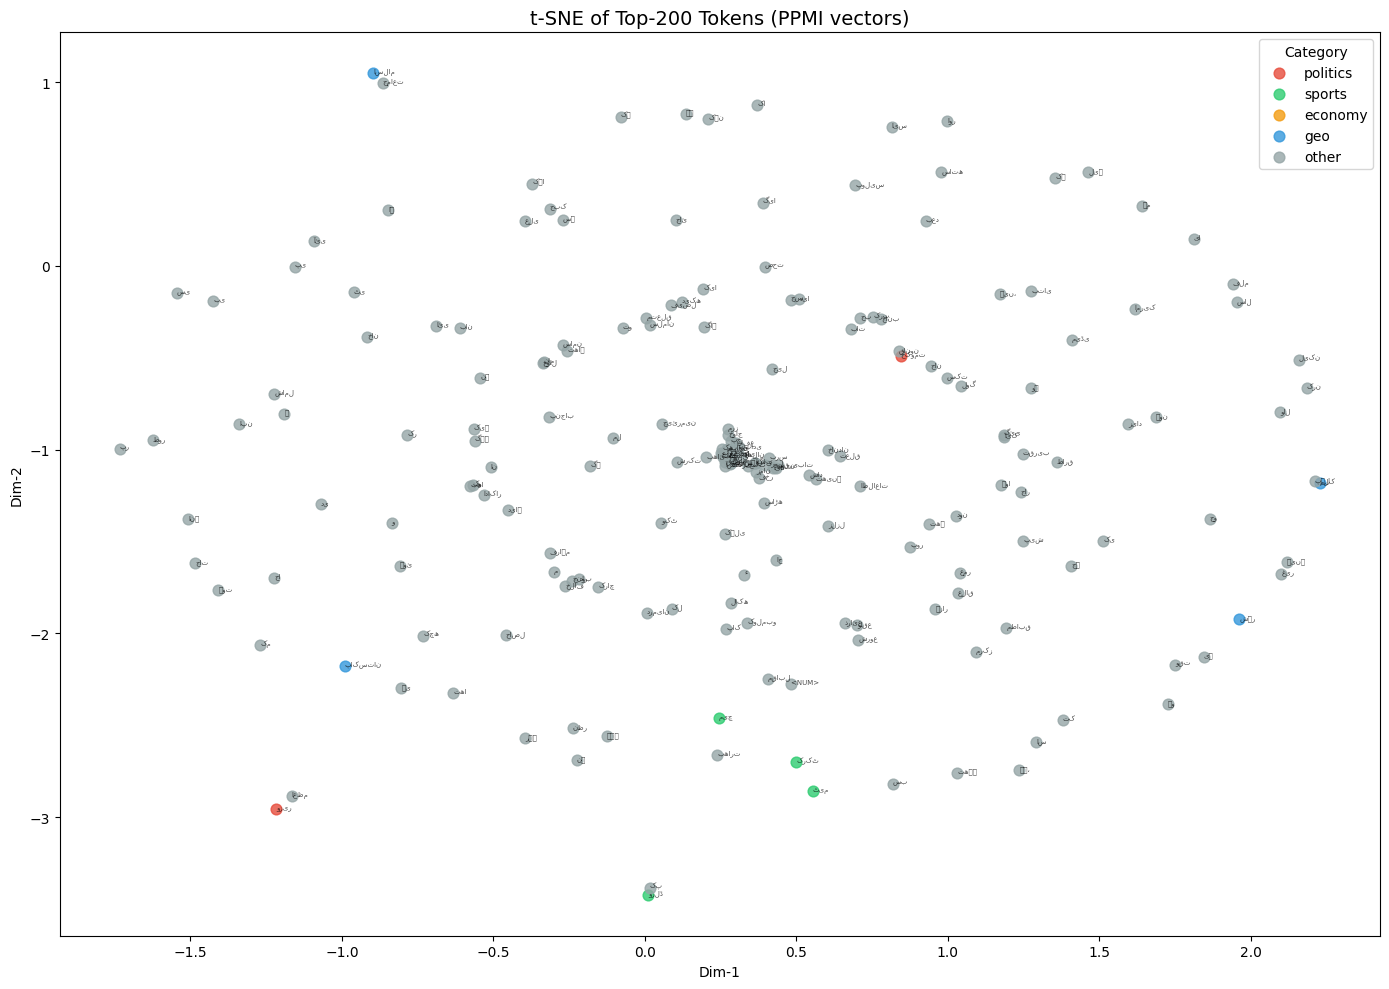

Saved: tsne_ppmi.png


In [9]:
# ── t-SNE visualisation of 200 most frequent tokens ──────────────────────────
top200_tokens = [w for w, _ in freq.most_common(200) if w in vocab]
top200_idx    = [vocab[w] for w in top200_tokens]
top200_vecs   = ppmi_matrix[top200_idx]   # (200, V)

# Assign a coarse colour from token keywords
CATEGORY_WORDS = {
    'politics': ['حکومت','وزیر','پارلیمنٹ','الیکشن','صدر','وزارت','سیاست'],
    'sports'  : ['کرکٹ','میچ','ٹیم','کھلاڑ','ورلڈ','اسکور'],
    'economy' : ['روپ','بینک','تجارت','مہنگائ','بجٹ','سرمایہ'],
    'geo'     : ['پاکستان','کراچی','لاہور','اسلام','ملک','شہر','صوبہ'],
}
COLORS = {'politics':'#e74c3c','sports':'#2ecc71','economy':'#f39c12','geo':'#3498db','other':'#95a5a6'}

def get_category(w):
    for cat, kws in CATEGORY_WORDS.items():
        if w in kws:
            return cat
    return 'other'

cats   = [get_category(w) for w in top200_tokens]
colors = [COLORS[c] for c in cats]

print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=SEED, init='random')
coords = tsne.fit_transform(top200_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
for cat in COLORS:
    mask = [c == cat for c in cats]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=COLORS[cat], label=cat, alpha=0.8, s=60)

for i, word in enumerate(top200_tokens):
    ax.annotate(word, coords[i], fontsize=5, alpha=0.7)

ax.set_title('t-SNE of Top-200 Tokens (PPMI vectors)', fontsize=14)
ax.set_xlabel('Dim-1')
ax.set_ylabel('Dim-2')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('tsne_ppmi.png', dpi=150)
plt.show()
print('Saved: tsne_ppmi.png')

In [10]:
# ── Nearest neighbours (cosine similarity) for 10 query words ────────────────
def cosine_nn(matrix, vocab, idx2word, query, top_k=5):
    if query not in vocab:
        return []
    idx  = vocab[query]
    vec  = matrix[idx].reshape(1, -1)
    sims = cosine_similarity(vec, matrix)[0]   # (V,)
    sims[idx] = -1                             # exclude self
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(idx2word[i], float(sims[i])) for i in top_idx]

QUERY_WORDS_PPMI = [
    'پاکستان','حکومت','کرکٹ','بینک','اسکول','ہسپتال','پولیس','عدالت','فوج','ملک'
]
print('Top-5 nearest neighbours (PPMI / cosine similarity):')
for qw in QUERY_WORDS_PPMI:
    nbs = cosine_nn(ppmi_matrix, vocab, idx2word, qw, top_k=5)
    print(f'  {qw}: {nbs}')

Top-5 nearest neighbours (PPMI / cosine similarity):
  پاکستان: [('کرکٹ', 0.17583395540714264), ('کے', 0.17137792706489563), ('بھارت', 0.1702083796262741), ('ٹیم', 0.1663493812084198), ('میچ', 0.16588406264781952)]
  حکومت: [('ہمدرد', 0.16403603553771973), ('ہوگی۔', 0.16383124887943268), ('قانون', 0.15741020441055298), ('منعم', 0.1554681956768036), ('ذمہ', 0.15509545803070068)]
  کرکٹ: [('بورڈ', 0.32589396834373474), ('شائقین', 0.26509636640548706), ('دنیائ', 0.21156302094459534), ('کولمبو', 0.20622500777244568), ('میدان', 0.19102513790130615)]
  بینک: [('اسٹیٹ', 0.4012026786804199), ('بافٹ', 0.3511936664581299), ('سینٹر', 0.34306442737579346), ('رقوم', 0.3149406313896179), ('رائل', 0.3109753131866455)]
  اسکول: [('پرفارمنگ', 0.5352590680122375), ('ارٹس', 0.39888301491737366), ('اسکالرشپ', 0.355796217918396), ('گلاسگو', 0.33913272619247437), ('کلائمبنگ', 0.31998592615127563)]
  ہسپتال: [('شفا', 0.3842533826828003), ('منتقل', 0.34855449199676514), ('خانم', 0.2925460636615753), ('گدے', 0